C:\Users\khris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Diskon yang didapat: 25.54263565891474%


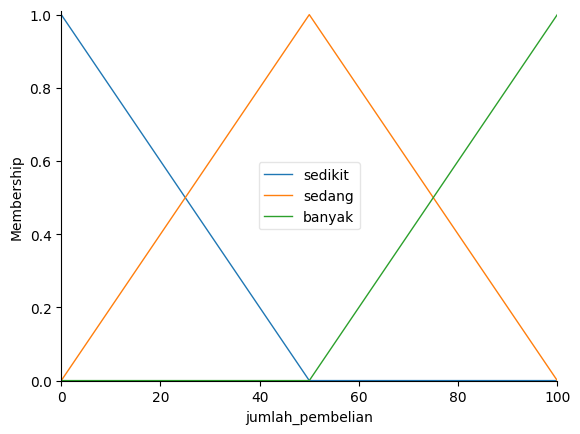

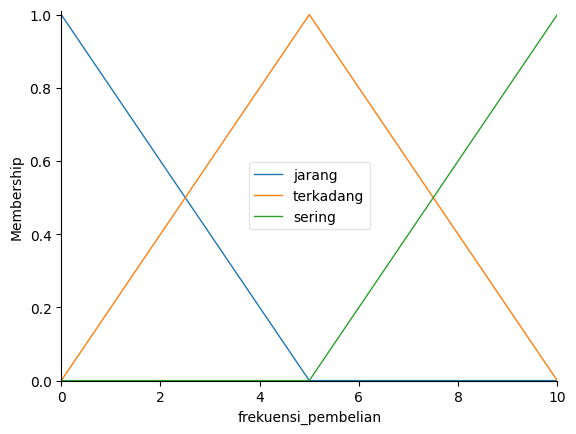

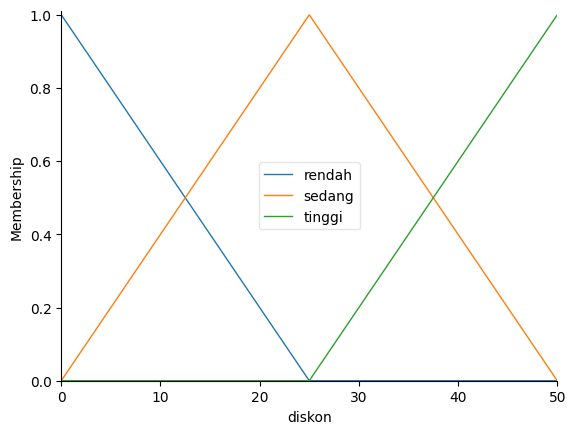

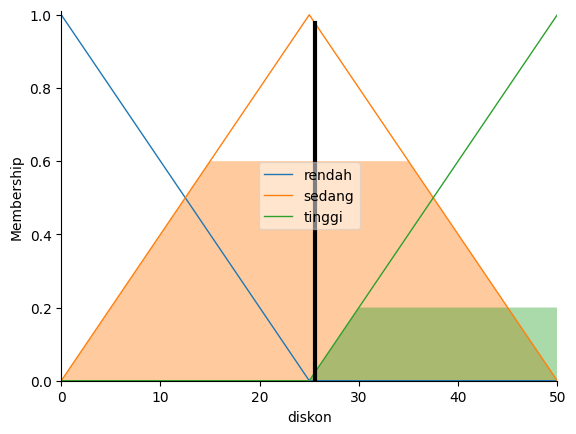

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Membuat variabel input: Jumlah Pembelian dan Frekuensi Pembelian
jumlah_pembelian = ctrl.Antecedent(np.arange(0, 101, 1), 'jumlah_pembelian')
frekuensi_pembelian = ctrl.Antecedent(np.arange(0, 11, 1), 'frekuensi_pembelian')

# Membuat variabel output: Diskon
diskon = ctrl.Consequent(np.arange(0, 51, 1), 'diskon')

# Mendefinisikan fungsi keanggotaan untuk 'jumlah_pembelian'
jumlah_pembelian['sedikit'] = fuzz.trimf(jumlah_pembelian.universe, [0, 0, 50])
jumlah_pembelian['sedang'] = fuzz.trimf(jumlah_pembelian.universe, [0, 50, 100])
jumlah_pembelian['banyak'] = fuzz.trimf(jumlah_pembelian.universe, [50, 100, 100])

# Mendefinisikan fungsi keanggotaan untuk 'frekuensi_pembelian'
frekuensi_pembelian['jarang'] = fuzz.trimf(frekuensi_pembelian.universe, [0, 0, 5])
frekuensi_pembelian['terkadang'] = fuzz.trimf(frekuensi_pembelian.universe, [0, 5, 10])
frekuensi_pembelian['sering'] = fuzz.trimf(frekuensi_pembelian.universe, [5, 10, 10])

# Mendefinisikan fungsi keanggotaan untuk 'diskon'
diskon['rendah'] = fuzz.trimf(diskon.universe, [0, 0, 25])
diskon['sedang'] = fuzz.trimf(diskon.universe, [0, 25, 50])
diskon['tinggi'] = fuzz.trimf(diskon.universe, [25, 50, 50])

# Menampilkan grafis keanggotaan
jumlah_pembelian.view()
frekuensi_pembelian.view()
diskon.view()

# Aturan fuzzy
rule1 = ctrl.Rule(jumlah_pembelian['banyak'] & frekuensi_pembelian['sering'], diskon['tinggi'])
rule2 = ctrl.Rule(jumlah_pembelian['sedang'] & frekuensi_pembelian['terkadang'], diskon['sedang'])
rule3 = ctrl.Rule(jumlah_pembelian['sedikit'] & frekuensi_pembelian['jarang'], diskon['rendah'])

# Membuat sistem kontrol
diskon_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
diskon_calculator = ctrl.ControlSystemSimulation(diskon_ctrl)

# Menginput nilai untuk jumlah pembelian dan frekuensi pembelian
diskon_calculator.input['jumlah_pembelian'] = 60
diskon_calculator.input['frekuensi_pembelian'] = 7

# Melakukan komputasi
diskon_calculator.compute()

# Menampilkan hasil diskon
print(f"Diskon yang didapat: {diskon_calculator.output['diskon']}%")

# Menampilkan hasil plot
diskon.view(sim=diskon_calculator)
